In [2]:
import numpy as np
import matplotlib.pyplot as plt 

def show_mask(mask, ax, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        color = np.array([30/255, 144/255, 255/255, 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)
    
def show_points(coords, labels, ax, marker_size=375):
    pos_points = coords[labels==1]
    neg_points = coords[labels==0]
    ax.scatter(pos_points[:, 0], pos_points[:, 1], color='green', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)
    ax.scatter(neg_points[:, 0], neg_points[:, 1], color='red', marker='*', s=marker_size, edgecolor='white', linewidth=1.25)   
    
def show_box(box, ax):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor='green', facecolor=(0,0,0,0), lw=2))

In [9]:
from segment_anything import SamPredictor, sam_model_registry
import cv2 

#sam = sam_model_registry['vit_b'](checkpoint="sam_vit_b_01ec64.pth")
#sam = sam_model_registry['vit_l'](checkpoint="sam_vit_l_0b3195.pth")
sam = sam_model_registry['vit_h'](checkpoint="sam_vit_h_4b8939.pth")
predictor = SamPredictor(sam)


In [10]:
rutaImagen = "../Lobos_marinos.jpg"
image = cv2.imread(rutaImagen)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

predictor.set_image(image) # Image Encoder

KeyboardInterrupt: 

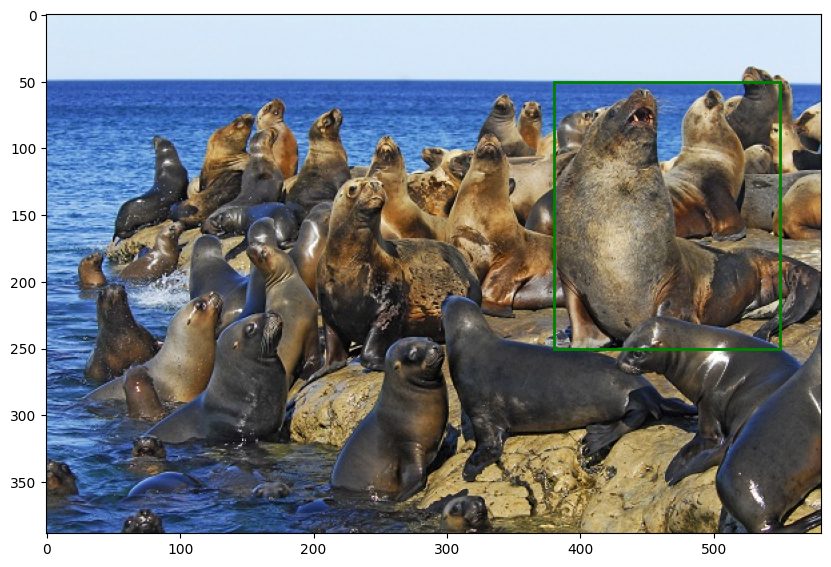

In [ ]:
# david.jpg
#input_point = np.array([[650, 200], [610, 50], [600, 400], [800, 700]]) # (x, y)
#input_label = np.array([1, 1, 0, 1])
#input_point = np.array([[450, 150]]) # (x, y)
input_label = np.array([1])
input_box = np.array([380, 50, 550, 250]) # xyxy


plt.figure(figsize=(10, 10))
plt.imshow(image)
#show_points(input_point, input_label, plt.gca())
show_box(input_box, plt.gca())
plt.axis('on')
plt.show()

In [ ]:
masks, scores, logits = predictor.predict(
    #point_coords=input_point,
    box=input_box,
    point_labels=input_label,
    multimask_output=True
)

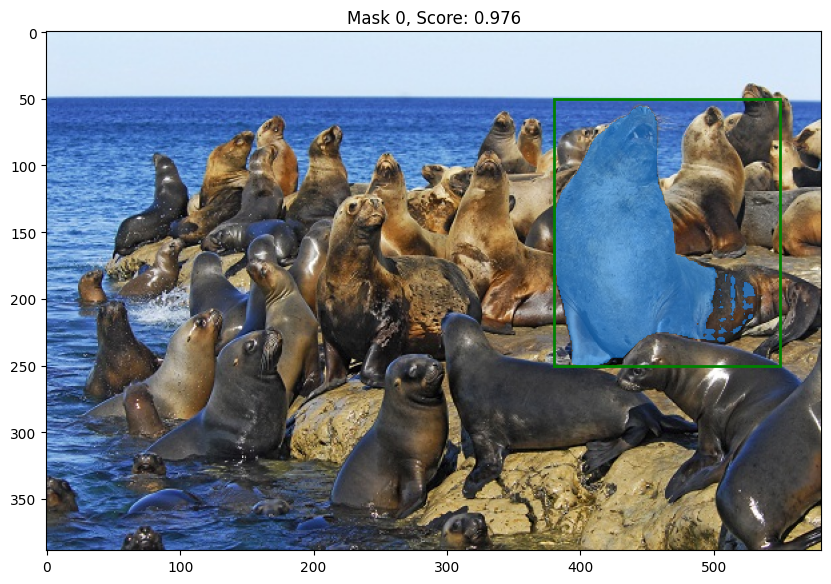

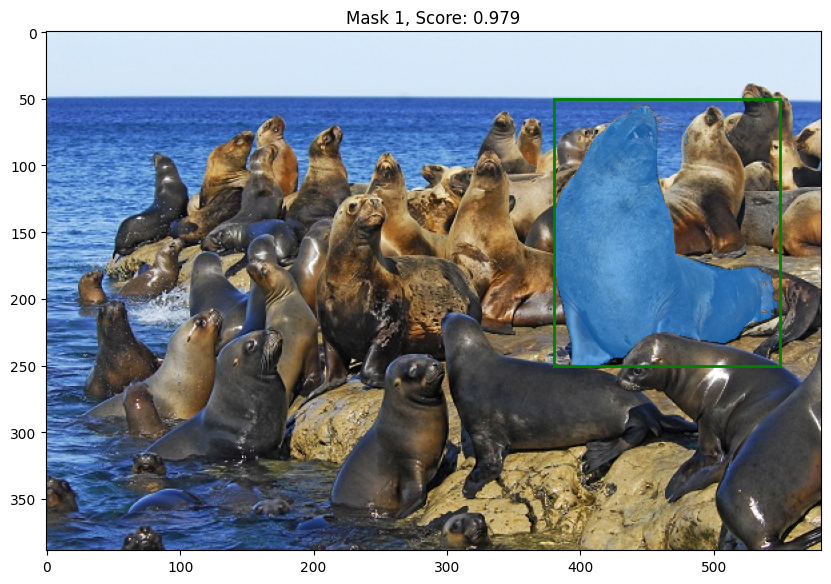

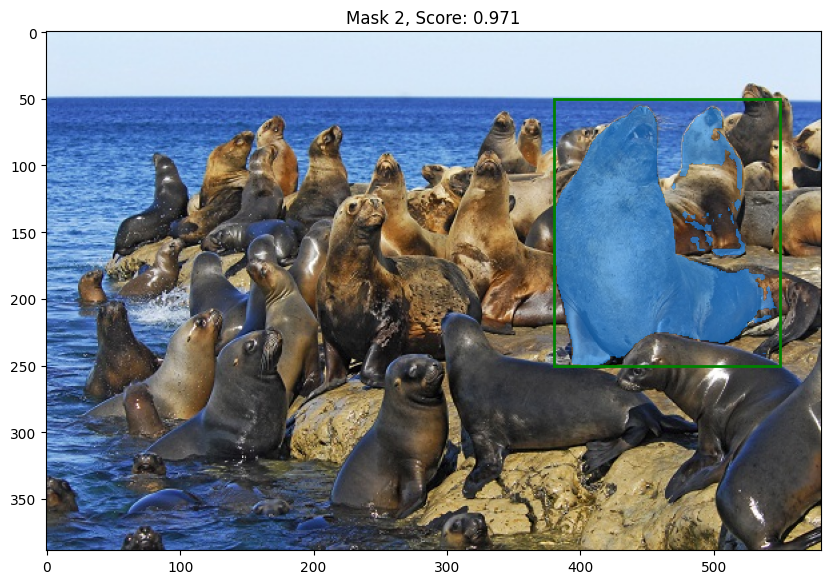

In [ ]:
for i, (mask, score) in enumerate(zip(masks, scores)):
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    show_mask(mask, plt.gca())
    #show_points(input_point, input_label, plt.gca())
    show_box(input_box, plt.gca())
    plt.title(f"Mask {i}, Score: {score:.3f}")
    plt.axis('on')
    plt.show()

# BATCH PROMPT

In [ ]:
import torch 

input_boxes = torch.tensor([[380, 50, 550, 250],
                       [200, 250, 300, 360],
                       [50, 75, 110, 155]], device=predictor.device)

transformed_boxes = predictor.transform.apply_boxes_torch(input_boxes, image.shape[:2])
masks, _, _ = predictor.predict_torch(
    point_coords=None,
    point_labels=None,
    boxes=transformed_boxes,
    multimask_output=False
)

In [ ]:
masks.shape

torch.Size([3, 1, 389, 581])

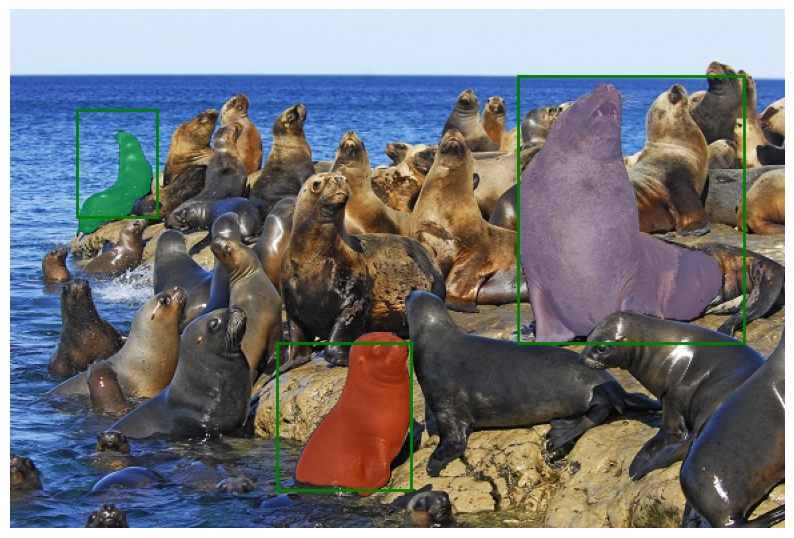

In [ ]:
plt.figure(figsize=(10, 10))
plt.imshow(image)

for mask in masks:
    show_mask(mask.cpu().numpy(), plt.gca(), random_color=True)

for box in input_boxes:
    show_box(box.cpu().numpy(), plt.gca())

plt.axis('off')
plt.show()